# Library Import

In [5]:
import pandas as pd
import numpy as np
import re
import string

import nltk
nltk.download('stopwords')

from nltk.corpus import stopwords

!pip install Sastrawi
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import SpatialDropout1D
from tensorflow.keras.layers import Bidirectional
from tensorflow.keras.callbacks import ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.layers import GlobalMaxPooling1D
import matplotlib.pyplot as plt
import seaborn as sns

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# Load Dataset

In [6]:
df = pd.read_csv('dataset_sentiment.csv')

# Preview 10 sample from dataset
df.head()

,app,review,score
0,Gojek,untuk gerai gofood kenapa cuma muter2 area itu...,1
1,Gojek,bagus,5
2,Gojek,top,5
3,Gojek,sangat membantu sbnarnya...cuma disaat liburan...,5
4,Gojek,terbaik,5


# **Labeling**

In [7]:
# Polarity function
def labeling(score):  # Convert numeric score to Sentimen Label
    if score >= 4:
        return 'positif'
    else:
        return 'negatif'

df['sentiment'] = df['score'].apply(labeling)
df['sentiment'].value_counts()

,count
sentiment,
negatif,9479
positif,8590


# **Preprocessing**

## Stopwords & Stemmer

In [8]:
# Stopwords
custom_stopwords = stopwords.words('indonesian')

negation_words = [
    'tidak',
    'bukan',
    'kurang',
    'jangan',
    'belum'
]

filtered_stopwords = [
    word for word in custom_stopwords
    if word not in negation_words
]

stop_words = set(filtered_stopwords)

# Stemmer
factory = StemmerFactory()
stemmer = factory.create_stemmer()

## Cleaning unique character

In [9]:
def clean_text(text):
    text = str(text).lower()
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    # Remove mentions and hashtags
    text = re.sub(r'@\w+|#\w+', '', text)
    # Remove digits
    text = re.sub(r'\d+', '', text)
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\s+', ' ', text).strip()

    words = text.split()
    words = [word for word in words if word not in stop_words]
    words = [stemmer.stem(word) for word in words]
    return ' '.join(words)

# apply cleaning functoin
df['clean_review'] = df['review'].apply(clean_text)

# Remove very short reviews
df = df[
    df['clean_review']
    .str.split()
    .str.len() >= 3
]

df.head() # show cleaning result

,app,review,score,sentiment,clean_review
0,Gojek,untuk gerai gofood kenapa cuma muter2 area itu...,1,negatif,gerai gofood muter area aja ypadahal sampe mun...
3,Gojek,sangat membantu sbnarnya...cuma disaat liburan...,5,positif,bantu sbnarnyacuma saat libur armada kota sy k...
5,Gojek,sangat puas untuk perjalanan nyaman,5,positif,puas jalan nyaman
11,Gojek,Sangat membantu sat set,5,positif,bantu sat set
12,Gojek,siap berangkat ke tujuan gak pakai ribet gak p...,5,positif,berangkat tuju gak pakai ribet gak pakai biaya...


## Encoding

In [10]:
label_mapping = {
    'negatif': 0,
    'positif': 1
}

df['label'] = df['sentiment'].map(label_mapping)

# **Splitting Data**

In [11]:
X = df['clean_review']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [12]:
# Split 70:30

X_train_70, X_test_70, y_train_70, y_test_70 = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# **Modeling Schema**

## Feature Extraction

In [13]:
# Feature Extraction with TF-IDF
tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1,3),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [21]:
    # Tokenizer Declare
max_words = 10000
max_len = 50

tokenizer = Tokenizer(
    num_words=max_words,
    oov_token="<OOV>"
)
tokenizer.fit_on_texts(X_train_70)

# Apply Tokenizer
X_train_seq = tokenizer.texts_to_sequences(X_train_70)
X_test_seq = tokenizer.texts_to_sequences(X_test_70)

# Padding
X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=max_len,
    padding='post',
    truncating='post'
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=max_len,
    padding='post',
    truncating='post'
)

# One Hot Encoding
y_train_cat = to_categorical(y_train_70, num_classes=2)
y_test_cat = to_categorical(y_test_70, num_classes=2)

## Schema 1: TF-IDF + Logistic Regression

In [15]:
# Training
lr_model = LogisticRegression(
    max_iter=1000,
    C=5.0,
    class_weight='balanced',
    solver='lbfgs',
    random_state=42
)
lr_model.fit(X_train_tfidf, y_train)

# Evaluasi
y_pred_lr = lr_model.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Accuracy: 0.8575478384124734
              precision    recall  f1-score   support

           0       0.87      0.90      0.89      1750
           1       0.83      0.79      0.81      1072

    accuracy                           0.86      2822
   macro avg       0.85      0.84      0.85      2822
weighted avg       0.86      0.86      0.86      2822



In [16]:
# Train Accuracy
train_pred_lr = lr_model.predict(X_train_tfidf)
train_acc_lr = accuracy_score(
    y_train,
    train_pred_lr
)

print("Training Accuracy Logistic Regression:",
      train_acc_lr)

# Testing Accuracy
test_acc_lr = accuracy_score(
    y_test,
    y_pred_lr
)

print("Test Accuracy Logistic Regression:",
      test_acc_lr)

Training Accuracy Logistic Regression: 0.9689022769557899
Test Accuracy Logistic Regression: 0.8575478384124734


## Schema 2: TF-IDF + SVM

In [17]:
# Train
svm_model = LinearSVC(
    class_weight='balanced',
    C=0.5
)
svm_model.fit(X_train_tfidf, y_train)

# Predict
y_pred_svm = svm_model.predict(X_test_tfidf)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

Accuracy: 0.8582565556343019
              precision    recall  f1-score   support

           0       0.87      0.91      0.89      1750
           1       0.83      0.78      0.81      1072

    accuracy                           0.86      2822
   macro avg       0.85      0.84      0.85      2822
weighted avg       0.86      0.86      0.86      2822



In [18]:
# Train Accuracy
train_pred_svm = svm_model.predict(
    X_train_tfidf
)
train_acc_svm = accuracy_score(
    y_train,
    train_pred_svm
)

print("Training Accuracy SVM:",
      train_acc_svm)

# Testing Accuracy
test_acc_svm = accuracy_score(
    y_test,
    y_pred_svm
)

print("Test Accuracy SVM:",
      test_acc_svm)

Training Accuracy SVM: 0.9725347745193585
Test Accuracy SVM: 0.8582565556343019


## Schema 3: Tokenizer + LSTM

In [22]:
model = Sequential([
    Embedding(max_words, 128),
    SpatialDropout1D(0.3),
    Bidirectional(
        LSTM(
            32,
            return_sequences=True,
            dropout=0.3,
            recurrent_dropout=0.3
        )
    ),
    GlobalMaxPooling1D(),
    Dense(32, activation='relu'),
    Dropout(0.5),
    Dense(2, activation='softmax')
])

model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_1          │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [23]:
# Early Stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

# Callback
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=1,
    verbose=1
)

# Class Weight
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(
    enumerate(class_weights)
)

print(class_weights)

# Train
history = model.fit(
    X_train_pad,
    y_train_cat,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weights,
    verbose=0
)

# Evaluation
loss, accuracy = model.evaluate(X_test_pad, y_test_cat)

print("Test Accuracy:", accuracy)

{0: np.float64(0.806559954266114), 1: np.float64(1.3155011655011655)}

Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8594 - loss: 0.3585
Test Accuracy: 0.8594377636909485


In [24]:
print("Final Training Accuracy:",
      history.history['accuracy'][-1])

print("Final Validation Accuracy:",
      history.history['val_accuracy'][-1])

loss, accuracy = model.evaluate(
    X_test_pad,
    y_test_cat
)

print("Test Accuracy:", accuracy)

Final Training Accuracy: 0.9259493947029114
Final Validation Accuracy: 0.8471660017967224
133/133 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.8594 - loss: 0.3585
Test Accuracy: 0.8594377636909485


# **Inference**

In [25]:
sample_text = [
    "aplikasinya sangat membantu dan fiturnya bagus"
]

sample_clean = [clean_text(text) for text in sample_text]

Logistic Regression

In [26]:
sample_tfidf = tfidf.transform(sample_clean)
prediction = lr_model.predict(sample_tfidf)

reverse_label = {
    0: 'negatif',
    1: 'positif'
}

print("Prediksi:", reverse_label[prediction[0]])

Prediksi: positif


# **Evaluation**

Confusion Matrix

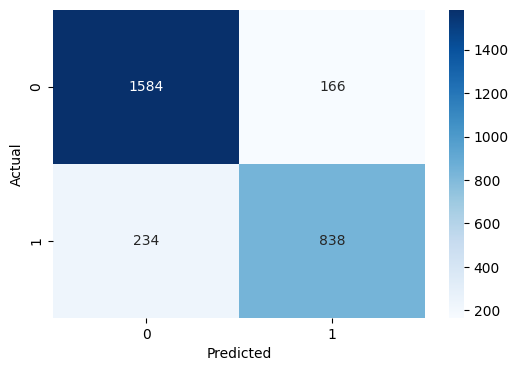

In [27]:
cm = confusion_matrix(y_test, y_pred_svm)

# Visualitation
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [28]:
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'SVM',
        'BiLSTM'
    ],
    'Train Accuracy': [
        train_acc_lr,
        train_acc_svm,
        history.history['accuracy'][-1]
    ],
    'Validation Accuracy': [
        None,
        None,
        history.history['val_accuracy'][-1]
    ],
    'Test Accuracy': [
        test_acc_lr,
        test_acc_svm,
        accuracy
    ]
})

results

,Model,Train Accuracy,Validation Accuracy,Test Accuracy
0,Logistic Regression,0.968902,NaN,0.857548
1,SVM,0.972535,NaN,0.858257
2,BiLSTM,0.925949,0.847166,0.859438
